In [2]:
import yfinance as yf
import pandas as pd

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']

raw_data = {}

for ticker in tickers:
    df = yf.download(ticker, start='2019-01-01', end='2024-01-01', auto_adjust=True)
    raw_data[ticker] = df
    print(f"Downloaded {ticker}: {len(df)} rows")
    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Downloaded AAPL: 1258 rows
Downloaded MSFT: 1258 rows


[*********************100%***********************]  1 of 1 completed

Downloaded GOOGL: 1258 rows



[*********************100%***********************]  1 of 1 completed


Downloaded AMZN: 1258 rows


[*********************100%***********************]  1 of 1 completed

Downloaded JPM: 1258 rows


In [4]:
def add_target(df):
    # Flatten multi-level columns if yfinance returned them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df['future_close'] = df['Close'].shift(-5)
    df['target'] = (df['future_close'] > df['Close']).astype(int)
    df.drop(columns=['future_close'], inplace=True)
    return df

for ticker in tickers:
    raw_data[ticker] = add_target(raw_data[ticker])

print(raw_data['AAPL'][['Close', 'target']].tail(10))
print("\nTarget value counts:")
print(raw_data['AAPL']['target'].value_counts())

Price            Close  target
Date                          
2023-12-15  195.358658       0
2023-12-18  193.697449       0
2023-12-19  194.735703       0
2023-12-20  192.649338       0
2023-12-21  192.500992       0
2023-12-22  191.433090       0
2023-12-26  190.889252       0
2023-12-27  190.988129       0
2023-12-28  191.413330       0
2023-12-29  190.375076       0

Target value counts:
target
1    758
0    500
Name: count, dtype: int64


In [5]:
def add_return_features(df):
    df['return_1d'] = df['Close'].pct_change(1)
    df['return_5d'] = df['Close'].pct_change(5)
    df['return_20d'] = df['Close'].pct_change(20)
    return df

def add_moving_averages(df):
    df['sma_20'] = df['Close'].rolling(window=20).mean()
    df['sma_50'] = df['Close'].rolling(window=50).mean()
    df['price_to_sma20'] = df['Close'] / df['sma_20']
    df['price_to_sma50'] = df['Close'] / df['sma_50']
    df['sma_cross'] = (df['sma_20'] > df['sma_50']).astype(int)
    return df

def add_rsi(df, window=14):
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    return df

def add_macd(df):
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    return df

def add_bollinger_bands(df):
    sma = df['Close'].rolling(window=20).mean()
    std = df['Close'].rolling(window=20).std()
    df['bb_upper'] = sma + (2 * std)
    df['bb_lower'] = sma - (2 * std)
    df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / sma
    return df

def add_volume_features(df):
    df['volume_sma20'] = df['Volume'].rolling(window=20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma20']
    return df

def build_features(df):
    df = add_return_features(df)
    df = add_moving_averages(df)
    df = add_rsi(df)
    df = add_macd(df)
    df = add_bollinger_bands(df)
    df = add_volume_features(df)
    df.dropna(inplace=True)
    return df

# Run on all tickers and combine
all_data = []

for ticker in tickers:
    df = build_features(raw_data[ticker].copy())
    df['ticker'] = ticker
    all_data.append(df)

master_df = pd.concat(all_data)

print(f"Total rows: {len(master_df)}")
print(f"Total columns: {len(master_df.columns)}")
print(f"\nColumn names:")
print(master_df.columns.tolist())

Total rows: 6045
Total columns: 25

Column names:
['Close', 'High', 'Low', 'Open', 'Volume', 'target', 'return_1d', 'return_5d', 'return_20d', 'sma_20', 'sma_50', 'price_to_sma20', 'price_to_sma50', 'sma_cross', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_position', 'bb_width', 'volume_sma20', 'volume_ratio', 'ticker']


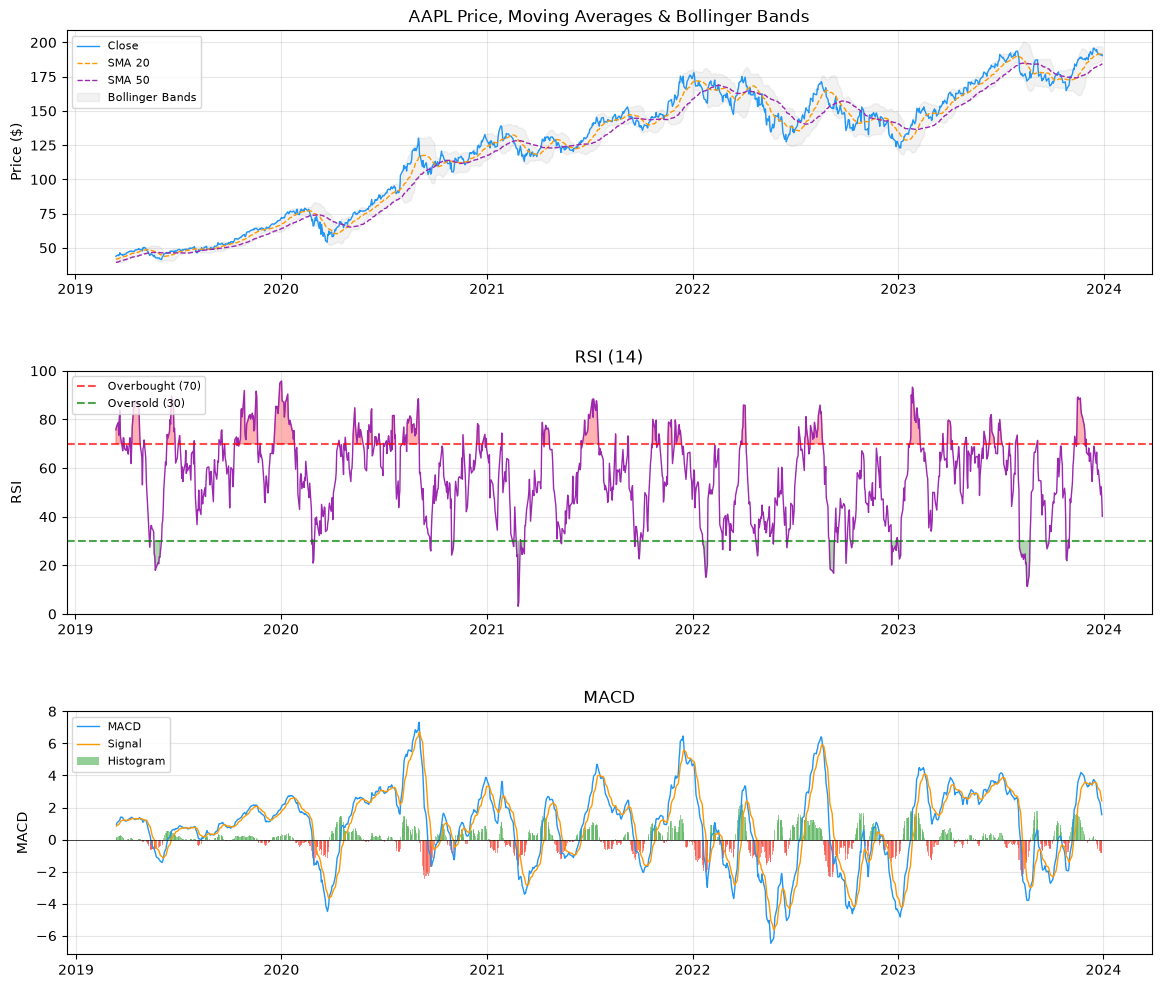

Chart saved as aapl_indicators.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

aapl = master_df[master_df['ticker'] == 'AAPL'].copy()

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 1, hspace=0.4)

# --- Chart 1: Price + Moving Averages + Bollinger Bands ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(aapl.index, aapl['Close'], label='Close', linewidth=1, color='#2196F3')
ax1.plot(aapl.index, aapl['sma_20'], label='SMA 20', linewidth=1, linestyle='--', color='#FF9800')
ax1.plot(aapl.index, aapl['sma_50'], label='SMA 50', linewidth=1, linestyle='--', color='#9C27B0')
ax1.fill_between(aapl.index, aapl['bb_upper'], aapl['bb_lower'], alpha=0.1, color='gray', label='Bollinger Bands')
ax1.set_title('AAPL Price, Moving Averages & Bollinger Bands', fontsize=12)
ax1.legend(loc='upper left', fontsize=8)
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# --- Chart 2: RSI ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(aapl.index, aapl['rsi_14'], color='#9C27B0', linewidth=1)
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(aapl.index, aapl['rsi_14'], 70, where=(aapl['rsi_14'] >= 70), alpha=0.3, color='red')
ax2.fill_between(aapl.index, aapl['rsi_14'], 30, where=(aapl['rsi_14'] <= 30), alpha=0.3, color='green')
ax2.set_title('RSI (14)', fontsize=12)
ax2.legend(loc='upper left', fontsize=8)
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# --- Chart 3: MACD ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(aapl.index, aapl['macd'], label='MACD', linewidth=1, color='#2196F3')
ax3.plot(aapl.index, aapl['macd_signal'], label='Signal', linewidth=1, color='#FF9800')
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in aapl['macd_hist']]
ax3.bar(aapl.index, aapl['macd_hist'], color=colors, alpha=0.6, label='Histogram', width=2)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_title('MACD', fontsize=12)
ax3.legend(loc='upper left', fontsize=8)
ax3.set_ylabel('MACD')
ax3.grid(True, alpha=0.3)

plt.savefig('aapl_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as aapl_indicators.png")

In [7]:
import os

os.makedirs('data', exist_ok=True)
master_df.to_csv('data/features.csv')
print(f"Saved {len(master_df)} rows to data/features.csv")

Saved 6045 rows to data/features.csv
